# Functional programming


In [2]:
import numpy as np
import matplotlib.pyplot as plt

## Coding the solver
We will first code the algorithm above by writing a `run_diffusion` function that takes all necessary arguments.

<div style="background-color:#AABAB2; color: black; vertical-align: middle; padding:15px; margin: 10px; border-radius: 10px">
<b>Task 1.1:</b>   
Complete the missing parts in the code below
</div>

In [ ]:
def run_diffusion(
    L,       # length of the bar
    dx,      # discretization in space
    dt,      # discretization in time
    kappa,   # heat diffusivity
    T_init,  # initial temperature
    T_left,  # Temperature on the left
    h_right, # Flux on the right
    n_steps, # number of time steps
):
    assert kappa*dt/dx/dx<=0.5, 'Stability condition not satisfied'
    
    # spatial discretization
    x = np.arange(0, L+dx, dx)
    nx = len(x)

    # solution vectors
    T = np.zeros((n_steps,nx))

    # temperature field at t=0
    T[0,:] = # YOUR_CODE_LINE_HERE

    # loop through time
    for n in range(n_steps-1):
        # solution on the left
        T[n+1,0] = # YOUR_CODE_LINE_HERE

        # solution in the interior
        for m in range(1,nx-1):
            # YOUR_CODE_LINE_HERE

        # solution on the right
        T[n+1,-1] = # YOUR_CODE_LINE_HERE

    return x, T

In [1]:
def run_diffusion(
    L,       # length of the bar
    dx,      # discretization in space
    dt,      # discretization in time
    kappa,   # heat diffusivity
    T_init,  # initial temperature
    T_left,  # Temperature on the left
    h_right, # Flux on the right
    n_steps, # number of time steps
):
    assert kappa*dt/dx/dx<=0.5, 'Stability condition not satisfied'
    
    # spatial discretization
    x = np.arange(0, L+dx, dx)
    nx = len(x)

    # solution vectors
    T = np.zeros((n_steps,nx))

    # temperature field at t=0
    T[0,:] = T_init

    # loop through time
    for n in range(n_steps-1):
        # solution on the left
        T[n+1,0] = T_left

        # solution in the interior
        for m in range(1,nx-1):
            T[n+1,m] = T[n,m] + kappa*dt/dx/dx * (T[n,m+1]-2*T[n,m]+T[n,m-1])

        # solution on the right
        T[n+1,-1] = T[n,-1] + 2*kappa*dt/dx/dx * (T[n,-2] - T[n,-1] + h_right*dx)

    return x, T

## Running the code
Now let us use the code to run a simple diffusion example.

<div style="background-color:#AABAB2; color: black; vertical-align: middle; padding:15px; margin: 10px; border-radius: 10px">
<b>Task 1.2:</b>
Run the code for the following case:
    
- **Domain and discretization**: $L=1$, $\Delta x = 0.1$, $\Delta t = 0.001$

- **PDE parameters**: $\kappa=1$

- **Initial and boundary conditions**: $T_\mathrm{init}=25$, $T_\mathrm{left}=100$, $h_\mathrm{right}=0$

- **Solver parameters**: Run for 1000 time steps

After running, plot your solution over $x$ at time steps 0, 10, 100 and 999 together on the same plot

</div>

In [ ]:
# run the solver
x,T = # YOUR_CODE_LINE_HERE

# plot the solution
# YOUR_CODE_LINES_HERE

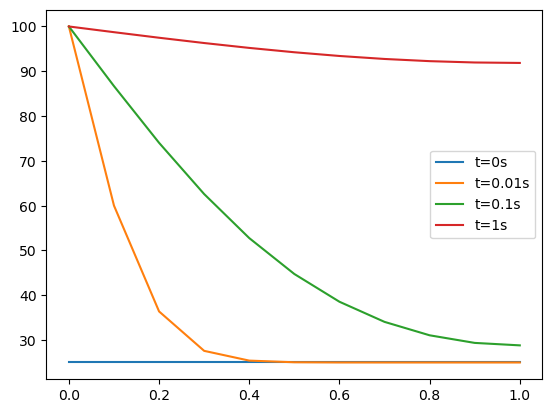

In [4]:
# run the solver
x,T = run_diffusion(L=1,
                      dx=0.1,
                      dt=0.001,
                      kappa=1,
                      T_init=25,
                      T_left=100,
                      h_right=0,
                      n_steps=1000
                     )

# plot the solution
plt.plot(x,T[0,:],label='t=0s')
plt.plot(x,T[10,:],label='t=0.01s')
plt.plot(x,T[100,:],label='t=0.1s')
plt.plot(x,T[-1,:],label='t=1s')
plt.legend();

See how even though the parameters can be neatly organized into the four logical groups above? Nevertheless, **they all get jammed together in the same function call** and the best we can do is to order them in some sensible way.

<div style="background-color:#AABAB2; color: black; vertical-align: middle; padding:15px; margin: 10px; border-radius: 10px">
<b>Task 1.3:</b> 
Repeat the same example from before but set $\kappa=5$
</div>

In [ ]:
# run the solver
x,T = # YOUR_CODE_LINE_HERE

# plot the solution
# YOUR_CODE_LINES_HERE

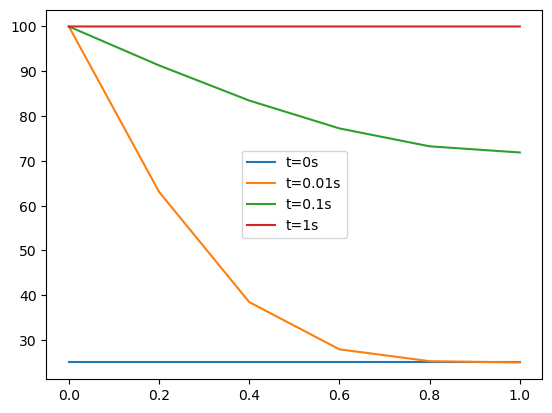

In [5]:
# run the solver
x,T = run_diffusion(L=1,
                      dx=0.1,
                      dt=0.001,
                      kappa=5,
                      T_init=25,
                      T_left=100,
                      h_right=0,
                      n_steps=1000
                     )

# plot the solution
plt.plot(x,T[0,:],label='t=0s')
plt.plot(x,T[10,:],label='t=0.01s')
plt.plot(x,T[100,:],label='t=0.1s')
plt.plot(x,T[-1,:],label='t=1s')
plt.legend();

Did you notice how to **change only one parameter** you had to repeat all the others? This is common in the functional programming paradigm: without global variables, functions calls tend to involve a large number of arguments and make the code look a bit clunky. It also involves a risk: maybe when copy/pasting you change some other parameter by mistake that you did not want to touch.

Also notice how you had to do the plotting manually again. You could have implemented a dedicated plotting function, but even then you would need to keep passing `x` and `T` between functions. Not very clean.

## Extending the solver

For the final task of this part, the goal is to code a modified version of the solver in which we do not apply a flux BC on the right but **another fixed temperature** $T_\mathrm{right}$. One possible way to do this is to add an `if` statement in the original code, but the function would then need **yet another argument** to inform it that the BC is now a fixed temperature and not a flux, otherwise it would have no way to discern that just from the value of the argument. Instead let us just code the whole thing again with a different name.

<div style="background-color:#AABAB2; color: black; vertical-align: middle; padding:15px; margin: 10px; border-radius: 10px">
<b>Task 1.4:</b>
Complete the missing parts in the code below
</div>

In [ ]:
def run_diffusion_two(
    L,       # length of the bar
    dx,      # discretization in space
    dt,      # discretization in time
    kappa,   # heat diffusivity
    T_init,  # initial temperature
    T_left,  # Temperature on the left
    T_right, # Temperature on the right
    n_steps, # number of time steps
):
    # YOUR_CODE_LINES_HERE

In [6]:
def run_diffusion_two(
    L,       # length of the bar
    dx,      # discretization in space
    dt,      # discretization in time
    kappa,   # heat diffusivity
    T_init,  # initial temperature
    T_left,  # Temperature on the left
    T_right, # Temperature on the right
    n_steps, # number of time steps
):
    assert kappa*dt/dx/dx<=0.5, 'Stability condition not satisfied'
    
    # spatial discretization
    x = np.arange(0, L+dx, dx)
    nx = len(x)

    # solution vectors
    T = np.zeros((n_steps,nx))

    # temperature field at t=0
    T[0,:] = T_init

    # loop through time
    for n in range(n_steps-1):
        # solution on the left
        T[n+1,0] = T_left

        # solution in the interior
        for m in range(1,nx-1):
            T[n+1,m] = T[n,m] + kappa*dt/dx/dx * (T[n,m+1]-2*T[n,m]+T[n,m-1])

        # solution on the right
        T[n+1,-1] = T_right

    return x, T

Let us now try it out. 

<div style="background-color:#AABAB2; color: black; vertical-align: middle; padding:15px; margin: 10px; border-radius: 10px">
<b>Task 1.5:</b> 

Run the new solver with the same parameter set of the first example ($\kappa=1$) but now with $T_\mathrm{right}=50$

</div>

In [ ]:
# run the solver
x,T = # YOUR_CODE_LINE_HERE

# plot the solution
# YOUR_CODE_LINES_HERE

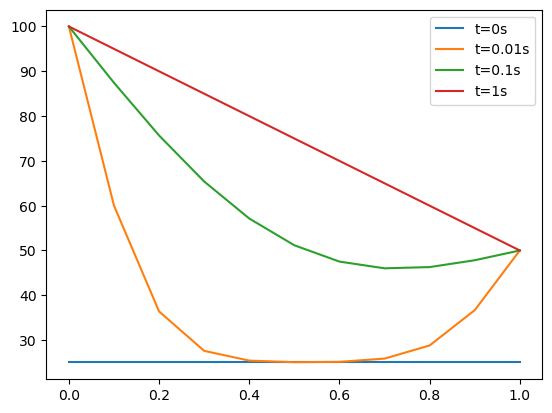

In [7]:
# run the solver
x,T = run_diffusion_two(L=1,
                      dx=0.1,
                      dt=0.001,
                      kappa=1,
                      T_init=25,
                      T_left=100,
                      T_right=50,
                      n_steps=1000
                     )

# plot the solution
plt.plot(x,T[0,:],label='t=0s')
plt.plot(x,T[10,:],label='t=0.01s')
plt.plot(x,T[100,:],label='t=0.1s')
plt.plot(x,T[-1,:],label='t=1s')
plt.legend();

Notice **how much code we had to repeat** in order to make such a small change. This is another drawback of functional programming: extending existing code often involves either a lot of repeated code or a convoluted set of `if-then-else` statements coupled with even more function arguments.

> By Iuri Rocha and Marcel Zijlema, Delft University of Technology. CC BY 4.0, more info [on the Credits page of Workbook](https://mude.citg.tudelft.nl/workbook-2025/credits.html).